### Main part

In [1]:
import mlflow

In [2]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")

In [3]:
import mlflow.artifacts
import mlflow.experiments
import mlflow.artifacts
import pickle
from sklearn.metrics import roc_auc_score, matthews_corrcoef
import pandas as pd
import matplotlib.patches as mpatches
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

In [4]:
runs_archs = mlflow.search_runs(experiment_ids=["564481821195479800", "892685210086593510","981963984580632175"])

In [5]:
from tqdm import tqdm

In [6]:
results_archs = []
for index, row in tqdm(runs_archs.iterrows()):
    chr = row["tags.mlflow.runName"].replace("_cpg_counts_selected", "").replace("chromosome_", "")
    trimming_type = "naive_cut"
    if row["experiment_id"] == "564481821195479800":
        trimming_l = 1000
    elif row["experiment_id"] == "981963984580632175":
        trimming_l = 500
    elif row["experiment_id"] == "892685210086593510":
        trimming_l = 150
    arch = row["tags.architecture"]
    tmp_path = mlflow.artifacts.download_artifacts (row["artifact_uri"] +"/predictions/test_whole_reads_predictions.pkl")
    f = open(tmp_path,'rb')
    predictions = pickle.load(f)
    f.close()
    mcc = matthews_corrcoef(predictions["true_label"],  predictions["predicted_probability"]>0.5)
    rocauc = roc_auc_score(predictions["true_label"],  predictions["predicted_probability"])
    results_archs.append((chr, trimming_type, rocauc, mcc,arch, trimming_l))

0it [00:00, ?it/s]x:\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
x:\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
x:\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
x:\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and

In [7]:
results_archs = pd.DataFrame(results_archs, columns=["chromosome", "trimming_type", "roc_auc", "mcc", "architecture", "trimming_length"])

In [8]:
results_archs = results_archs.loc[results_archs["chromosome"]!="chr5"]

In [9]:
results_archs["architecture"].unique()

array(['dismir_lstm', 'dnabert2', 'methylbert', 'dismir_minigru'],
      dtype=object)

In [10]:
results_archs["architecture"] = results_archs["architecture"].apply(lambda x: x.replace("dismir_lstm", "Dismir").
                                                                    replace("dismir_minigru", "Dismir-A").
                                                                    replace("dnabert2", "DNABERT-2E").
                                                                    replace("methylbert", "MethylBert"))

In [11]:
results_archs["architecture"].unique()

array(['Dismir', 'DNABERT-2E', 'MethylBert', 'Dismir-A'], dtype=object)

In [12]:
def create_model_comparison_plot(df, save_path=None, figsize=(14, 8)):
    """
    Create a comparison plot for multiple model architectures across chromosomes.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: chromosome, trimming_type, roc_auc, mcc, architecture
    save_path : str, optional
        Path to save the figure
    figsize : tuple
        Figure size (width, height)
    """
    
    # Pivot the data to get MCC values for each architecture
    pivot_mcc = df.pivot(index='chromosome', columns='architecture', values='mcc')
    
    # Sort chromosomes for better visualization
    # Extract chromosome numbers and sort
    chr_order = []
    for chr_name in pivot_mcc.index:
        if chr_name.startswith('chr'):
            try:
                num = int(chr_name[3:])
                chr_order.append((num, chr_name))
            except:
                # Handle chrX, chrY, etc.
                chr_order.append((100, chr_name))
    
    chr_order.sort()
    ordered_chromosomes = [chr_name for _, chr_name in chr_order]
    pivot_mcc = pivot_mcc.reindex(ordered_chromosomes)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Define colors and markers for each architecture
    architectures = df['architecture'].unique()
    colors = ['#A23B72', '#2E86AB', '#F18F01', '#7B4F9A'][:len(architectures)]
    markers = ['o', 's', '^', 'D'][:len(architectures)]
    marker_sizes = [100, 100, 120, 100][:len(architectures)]
    
    arch_styles = dict(zip(architectures, zip(colors, markers, marker_sizes)))
    
    # Plot data for each architecture
    x_positions = np.arange(len(pivot_mcc))
    
    for arch in architectures:
        if arch in pivot_mcc.columns:
            y_values = pivot_mcc[arch].values
            color, marker, size = arch_styles[arch]
            
            # Plot points
            ax.scatter(x_positions, y_values, c=color, marker=marker, s=size, 
                      alpha=0.7, edgecolors='black', linewidth=0.5, label=arch)
            
            # Connect points with a light line
            ax.plot(x_positions, y_values, color=color, alpha=0.3, linewidth=1)
    
    # Find best performer for each chromosome
    best_performers = []
    for idx, row in pivot_mcc.iterrows():
        max_mcc = row.max()
        if max_mcc > 0:  # Only highlight if there's actual performance
            best_arch = row.idxmax()
            best_performers.append((idx, best_arch, max_mcc))
            
            # Add a subtle highlight for the best performer
            x_idx = list(pivot_mcc.index).index(idx)
            ax.scatter(x_idx, max_mcc, s=300, facecolors='none', 
                      edgecolors='gold', linewidth=2, alpha=0.6)
    
    # Customize plot
    ax.set_xticks(x_positions)
    ax.set_xticklabels(pivot_mcc.index, rotation=45, ha='right')
    # ax.set_xlabel('Chromosome', fontsize=16)
    ax.set_ylabel('MCC', fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    # ax.set_title('Model Performance Comparison Across Chromosomes', 
    #             fontsize=14, fontweight='bold')
    
    # Add grid
    ax.grid(True, axis='y', alpha=0.3, linestyle=':')
    ax.set_ylim(-0.05, 1.05)
    
    # Add horizontal line at MCC=0.5 for reference
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    # Create legend
    # ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22),
          fancybox=True, shadow=True, ncol=4, fontsize = 20)
    
    # Calculate win statistics
    win_counts = {}
    for arch in architectures:
        win_counts[arch] = 0
    
    # Count wins (allowing for ties within 0.01 MCC)
    for idx, row in pivot_mcc.iterrows():
        max_mcc = row.max()
        if max_mcc > 0:
            # Find all architectures within 0.01 of the max
            winners = row[row >= max_mcc - 0.01].index.tolist()
            for winner in winners:
                win_counts[winner] += 1
    
    # # Add summary statistics box
    # stats_text = "Best Performance Count:\n"
    # for arch, count in sorted(win_counts.items(), key=lambda x: x[1], reverse=True):
    #     stats_text += f"{arch}: {count} chromosomes\n"
    
    # # Calculate average MCC for each architecture
    # stats_text += "\nAverage MCC:\n"
    # for arch in architectures:
    #     if arch in pivot_mcc.columns:
    #         avg_mcc = pivot_mcc[arch].mean()
    #         stats_text += f"{arch}: {avg_mcc:.3f}\n"
    
    # props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    # ax.text(0.98, 0.98, stats_text.strip(), transform=ax.transAxes, fontsize=10,
    #         verticalalignment='top', horizontalalignment='right', bbox=props)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax

In [13]:
def create_model_length_comparison_plot(df, save_path=None, figsize=(16, 8)):
    """
    Create a comparison plot for multiple model architectures across chromosomes and trimming lengths.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: chromosome, trimming_type, roc_auc, mcc, architecture, trimming_length
    save_path : str, optional
        Path to save the figure
    figsize : tuple
        Figure size (width, height)
    """
    
    # Sort chromosomes numerically
    def sort_chromosomes(chr_list):
        chr_nums = []
        for chr_name in chr_list:
            if chr_name.startswith('chr'):
                try:
                    num = int(chr_name[3:])
                    chr_nums.append((num, chr_name))
                except:
                    chr_nums.append((100, chr_name))  # For chrX, chrY, etc.
        chr_nums.sort()
        return [chr_name for _, chr_name in chr_nums]
    
    # Get unique values
    chromosomes = sort_chromosomes(df['chromosome'].unique())
    trimming_lengths = sorted(df['trimming_length'].unique())
    architectures = df['architecture'].unique()
    
    # Create x-axis positions
    n_lengths = len(trimming_lengths)
    n_chromosomes = len(chromosomes)
    
    # Group positions: each chromosome gets a group of positions for different lengths
    group_width = n_lengths + 0.5  # Space between chromosome groups
    x_positions = []
    x_labels = []
    chromosome_boundaries = []
    
    for i, chr_name in enumerate(chromosomes):
        start_pos = i * group_width
        chromosome_boundaries.append(start_pos - 0.25)
        for j, length in enumerate(trimming_lengths):
            x_pos = start_pos + j
            x_positions.append(x_pos)
            x_labels.append(f'{length}bp')
    
    chromosome_boundaries.append((n_chromosomes - 1) * group_width + n_lengths - 0.25)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Define colors and markers for each architecture
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#7B4F9A', '#2A9D8F'][:len(architectures)]
    markers = ['o', 's', '^', 'D', 'v'][:len(architectures)]
    marker_sizes = [80, 80, 100, 80, 100][:len(architectures)]
    
    arch_styles = dict(zip(architectures, zip(colors, markers, marker_sizes)))
    
    # Plot data for each architecture
    for arch in architectures:
        arch_data = df[df['architecture'] == arch]
        color, marker, size = arch_styles[arch]
        
        # Collect points for this architecture
        arch_x = []
        arch_y = []
        
        for i, chr_name in enumerate(chromosomes):
            chr_data = arch_data[arch_data['chromosome'] == chr_name]
            
            for j, length in enumerate(trimming_lengths):
                length_data = chr_data[chr_data['trimming_length'] == length]
                
                if not length_data.empty:
                    x_pos = i * group_width + j
                    mcc_value = length_data['mcc'].values[0]
                    
                    # Plot point
                    ax.scatter(x_pos, mcc_value, c=color, marker=marker, s=size,
                              alpha=0.8, edgecolors='black', linewidth=0.5)
                    
                    arch_x.append(x_pos)
                    arch_y.append(mcc_value)
        
        # Connect points for this architecture across different lengths within each chromosome
        for i, chr_name in enumerate(chromosomes):
            chr_x = []
            chr_y = []
            
            for j, length in enumerate(trimming_lengths):
                x_pos = i * group_width + j
                if x_pos in arch_x:
                    idx = arch_x.index(x_pos)
                    chr_x.append(x_pos)
                    chr_y.append(arch_y[idx])
            
            if len(chr_x) > 1:
                ax.plot(chr_x, chr_y, color=color, alpha=0.5, linewidth=1.5)
    
    # Add vertical lines to separate chromosomes
    for boundary in chromosome_boundaries[1:-1]:
        ax.axvline(x=boundary + 0.25, color='gray', linestyle=':', alpha=0.5)
    
    # Customize x-axis
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
    
    # Add chromosome labels
    for i, chr_name in enumerate(chromosomes):
        x_center = i * group_width + (n_lengths - 1) / 2
        ax.text(x_center, -0.15, chr_name, ha='center', va='top', 
                transform=ax.get_xaxis_transform(), fontsize=10, fontweight='bold')
    
    # Customize plot
    ax.set_ylabel('MCC', fontsize=12)
    ax.set_title('Model Performance Across Chromosomes and Trimming Lengths', 
                fontsize=14, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3, linestyle=':')
    ax.set_ylim(-0.05, 1.05)
    
    # Add horizontal reference line
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    # Create custom legend
    legend_elements = []
    for arch in architectures:
        color, marker, _ = arch_styles[arch]
        legend_elements.append(Line2D([0], [0], marker=marker, color='w', 
                                    markerfacecolor=color, markersize=10, 
                                    label=arch, markeredgecolor='black'))
    
    ax.legend(handles=legend_elements, loc='upper left', frameon=True, 
              fancybox=True, shadow=True)
    
    # # Add summary statistics
    # stats_text = "Average MCC by Length:\n"
    # for length in trimming_lengths:
    #     stats_text += f"\n{length}bp:\n"
    #     for arch in architectures:
    #         arch_length_data = df[(df['architecture'] == arch) & 
    #                              (df['trimming_length'] == length)]
    #         if not arch_length_data.empty:
    #             avg_mcc = arch_length_data['mcc'].mean()
    #             stats_text += f"  {arch}: {avg_mcc:.3f}\n"
    
    # props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    # ax.text(0.98, 0.98, stats_text.strip(), transform=ax.transAxes, fontsize=9,
    #         verticalalignment='top', horizontalalignment='right', bbox=props)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax

In [14]:
def create_length_scaling_plot(df, save_path=None, figsize=(12, 8)):
    """
    Create violin plots showing how performance scales with trimming length for each architecture.
    """
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Define colors for each architecture
    architectures = sorted(df['architecture'].unique())
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#7B4F9A', '#2A9D8F'][:len(architectures)]
    arch_colors = dict(zip(architectures, colors))
    
    # Get unique trimming lengths
    trimming_lengths = sorted(df['trimming_length'].unique())
    
    # Prepare data for violin plots
    positions = []
    violin_data = []
    colors_list = []
    valid_indices = []  # Track which positions have valid data
    
    # Width of groups and violins
    group_width = len(architectures) + 1
    violin_width = 0.8
    
    # Create position mapping
    pos_map = {}
    
    for i, length in enumerate(trimming_lengths):
        base_pos = i * group_width
        
        for j, arch in enumerate(architectures):
            pos = base_pos + j
            
            # Get data for this combination
            data = df[(df['trimming_length'] == length) & 
                     (df['architecture'] == arch)]['mcc'].values
            
            # Filter out NaN values
            data = data[~np.isnan(data)]
            
            # Only add to violin plot if we have data
            if len(data) > 0:
                positions.append(pos)
                violin_data.append(data)
                colors_list.append(arch_colors[arch])
                valid_indices.append(len(positions) - 1)
            
            # Store position for later use (even if no data)
            pos_map[(length, arch)] = pos
    
    # Create violin plots only if we have data
    if len(violin_data) > 0:
        parts = ax.violinplot(violin_data, positions=positions, widths=violin_width,
                             showmeans=True, showmedians=True, showextrema=True)
    
        # Customize violin colors
        for pc, color in zip(parts['bodies'], colors_list):
            pc.set_facecolor(color)
            pc.set_alpha(0.7)
            pc.set_edgecolor('black')
            pc.set_linewidth(0.5)
        
        # Customize other violin elements
        for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
            if partname in parts:
                vp = parts[partname]
                vp.set_edgecolor('black')
                vp.set_linewidth(1)
        
        # Add individual points
        for i, (pos, data) in enumerate(zip(positions, violin_data)):
            if len(data) > 0:
                # Add jittered points
                jittered_pos = np.random.normal(pos, 0.04, size=len(data))
                ax.scatter(jittered_pos, data, alpha=0.4, s=20, 
                          color=colors_list[i], edgecolor='black', linewidth=0.5)
    
    # Connect means across lengths for each architecture
    for arch in architectures:
        mean_positions = []
        mean_values = []
        
        for length in trimming_lengths:
            pos = pos_map[(length, arch)]
            data = df[(df['trimming_length'] == length) & 
                     (df['architecture'] == arch)]['mcc'].values
            
            if len(data) > 0:
                mean_positions.append(pos)
                mean_values.append(np.mean(data))
        
        if len(mean_positions) > 1:
            ax.plot(mean_positions, mean_values, 'o-', 
                   color=arch_colors[arch], linewidth=2, markersize=8,
                   markeredgecolor='black', markeredgewidth=1,
                   alpha=0.8, label=arch)
    
    # Customize x-axis
    group_centers = [(i * group_width + (len(architectures) - 1) / 2) 
                     for i in range(len(trimming_lengths))]
    ax.set_xticks(group_centers)
    ax.set_xticklabels([f'{length}bp' for length in trimming_lengths])
    plt.xticks(fontsize = 20)
    plt.yticks(fontsize = 20)
    # Add vertical lines to separate groups
    for i in range(1, len(trimming_lengths)):
        ax.axvline(x=i * group_width - 0.5, color='gray', 
                  linestyle=':', alpha=0.5)
    
    # Customize plot
    ax.set_xlabel('Trimming Length', fontsize=20)
    ax.set_ylabel('MCC', fontsize=20)
    # ax.set_title('Performance Distribution Across Trimming Lengths', 
    #             fontsize=14, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3, linestyle=':')
    ax.set_ylim(-0.05, 1.05)
    
    # Add legend
    # ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True,
    #          title='Architecture (mean trajectory)')

    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.07),
          fancybox=True, shadow=True, ncol=4,fontsize=20)
    
    # Add horizontal reference line
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    # # Add summary statistics box
    # stats_text = "Summary Statistics:\n"
    # for arch in architectures:
    #     stats_text += f"\n{arch}:\n"
    #     for length in trimming_lengths:
    #         data = df[(df['trimming_length'] == length) & 
    #                  (df['architecture'] == arch)]['mcc'].values
            
    #         # Filter out NaN values
    #         data = data[~np.isnan(data)]
            
    #         if len(data) > 0:
    #             mean_val = np.mean(data)
    #             median_val = np.median(data)
    #             non_zero = np.sum(data > 0)
    #             stats_text += f"  {length}bp: μ={mean_val:.3f}, M={median_val:.3f}, n={len(data)} ({non_zero} > 0)\n"
    
    # props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    # ax.text(0.98, 0.98, stats_text.strip(), transform=ax.transAxes, fontsize=8,
    #         verticalalignment='top', horizontalalignment='right', bbox=props)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax

In [15]:
results_pivot = results_archs.pivot_table(index =["chromosome"],columns =["trimming_length","architecture"], values =["mcc"]).round(3)
results_pivot.reset_index(inplace=True)
results_pivot["chr_n"] = results_pivot["chromosome"].apply(lambda x: int(x.replace("chr","")))
results_pivot = results_pivot.sort_values("chr_n")
results_pivot.drop("chr_n", inplace=True, axis=1)

C:\Users\rizdvanetskyi\AppData\Local\Temp\ipykernel_37860\3573892710.py:5: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  results_pivot.drop("chr_n", inplace=True, axis=1)


In [16]:
with pd.option_context('display.max_rows', 229, 'display.max_columns', 25, 'display.precision', 3):  # more options can be specified also
    print(results_archs.pivot_table(index =["chromosome"],columns =["trimming_length","architecture"], values =["mcc"]))

                       mcc                                               \
trimming_length       150                                   500           
architecture    DNABERT-2E Dismir Dismir-A MethylBert DNABERT-2E Dismir   
chromosome                                                                
chr1                 0.883  0.905    0.898      0.912      0.907  0.915   
chr10                0.513  0.522    0.355      0.362      0.539  0.673   
chr11                0.106  0.000    0.000      0.000      0.194  0.000   
chr12                0.000  0.000    0.000      0.000      0.172  0.000   
chr13               -0.016  0.000    0.000      0.000      0.245  0.000   
chr14                0.315  0.466    0.544      0.258      0.650  0.615   
chr15                0.243  0.000    0.000      0.000      0.349  0.112   
chr16                0.779  0.879    0.878      0.878      0.890  0.891   
chr17                0.011  0.103    0.000      0.000      0.456  0.298   
chr18                0.04

In [17]:
results_archs.groupby(["architecture","trimming_length"]).agg("mean", "mcc")

roc_auc       mcc
architecture trimming_length                    
DNABERT-2E   150              0.687283  0.234959
             500              0.807234  0.459013
             1000             0.871259  0.584808
Dismir       150              0.759712  0.265165
             500              0.806271  0.359665
             1000             0.813344  0.418975
Dismir-A     150              0.733407  0.234204
             500              0.737122  0.264518
             1000             0.752433  0.311341
MethylBert   150              0.693493  0.224294
             500              0.767953  0.273697

In [18]:
results_archs["architecture"].value_counts()

architecture
Dismir        63
DNABERT-2E    63
Dismir-A      63
MethylBert    42
Name: count, dtype: int64

(<Figure size 1200x500 with 1 Axes>, <Axes: ylabel='MCC'>)

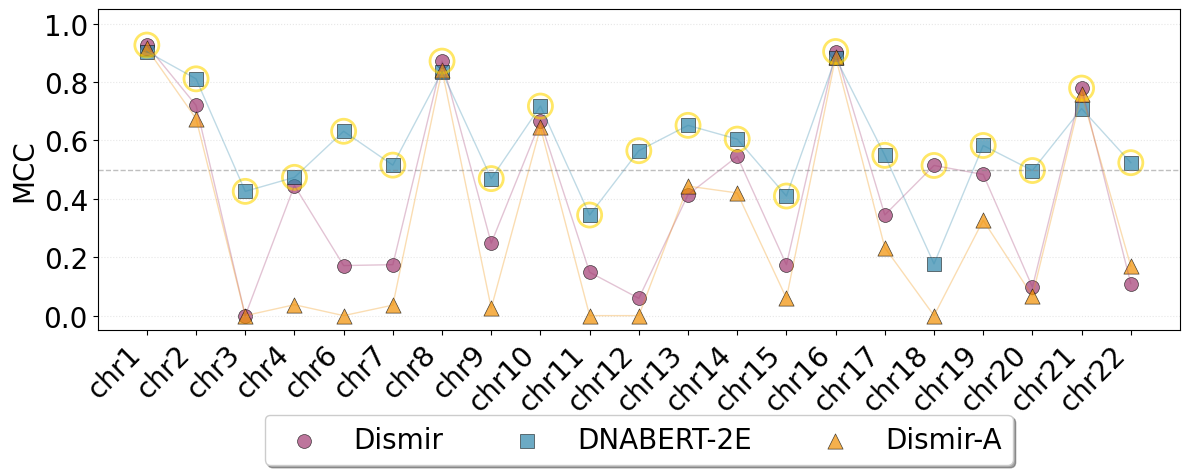

In [19]:
create_model_comparison_plot(results_archs.loc[results_archs["trimming_length"]==1000], figsize=(12, 5))

(<Figure size 1200x500 with 1 Axes>,
 <Axes: xlabel='Trimming Length', ylabel='MCC'>)

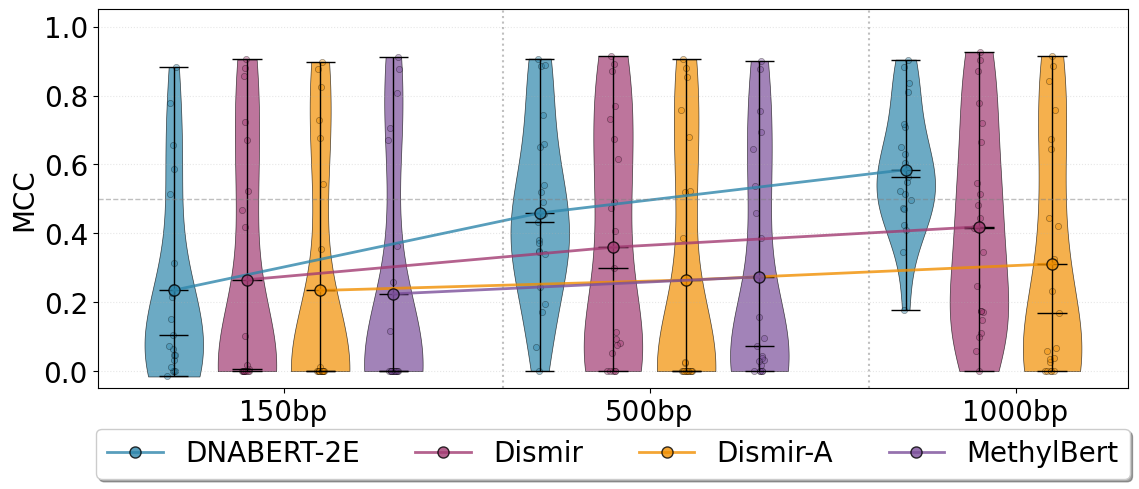

In [20]:
create_length_scaling_plot(results_archs,figsize=(12, 5))

### Whole-reads vs Chunk score distribution analysis

In [6]:
target_run = runs_archs[runs_archs["params.chromosome"]=="chr19"][runs_archs["tags.architecture"]=="dnabert2"][runs_archs["run_id"]=="ecf48474e9d145ffa31b3538437e39e9"]

C:\Users\rizdvanetskyi\AppData\Local\Temp\ipykernel_5548\3459325718.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  target_run = runs_archs[runs_archs["params.chromosome"]=="chr19"][runs_archs["tags.architecture"]=="dnabert2"][runs_archs["run_id"]=="ecf48474e9d145ffa31b3538437e39e9"]
C:\Users\rizdvanetskyi\AppData\Local\Temp\ipykernel_5548\3459325718.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  target_run = runs_archs[runs_archs["params.chromosome"]=="chr19"][runs_archs["tags.architecture"]=="dnabert2"][runs_archs["run_id"]=="ecf48474e9d145ffa31b3538437e39e9"]


In [7]:
from methyldl.modelling.dnabert2 import EpigenDnabert2
from methyldl.data.dataset import SupervisedDataset

x:\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
data_path = "../Data/Curated/rrms_dmrs_only_mincov40_corrected_top3000_dmr_cuts/chr19"

In [9]:
max_sequence_length=1000

In [10]:
tmp_path = mlflow.artifacts.download_artifacts (target_run["artifact_uri"].to_numpy()[0] +"/model/model.safetensors")

In [11]:
test_data = pd.read_parquet(data_path+"/test_whole_reads.parquet")
max_read_length = np.max([len(x) for x in test_data["input_ids"]])

Progressive predict

In [12]:
predictions = []
labels = []
max_sequence_lengths = []
read_names = []
for max_sequence_length in tqdm(reversed(range(1000, max_read_length+1,1000))):
    # print(max_sequence_length)
    subset_data = test_data[(test_data["sequence_length"]>max_sequence_length-1000) & (test_data["sequence_length"]<=max_sequence_length)]
    if subset_data.shape[0]:
        epigenbert = EpigenDnabert2(fine_tuned_model_path=tmp_path,max_sequence_length=max_sequence_length)
        # Load test dataset
        test_dataset = SupervisedDataset(
            tokenizer=epigenbert.tokenizer, 
            data_path_or_list=subset_data, 
            kmer=-1,
            data_interface="pandas"
        )
        
        if max_sequence_length>=16000:
            batch_size = 1
        elif max_sequence_length>8000:
            batch_size=1
        elif max_sequence_length>=7000:
            batch_size=5
        elif max_sequence_length>=6000:
            batch_size=15
        elif max_sequence_length>=5000:
            batch_size=30
        elif max_sequence_length>=4000:
            batch_size=45
        elif max_sequence_length>=2000:
            batch_size=100
        else:
            batch_size=240
        res_test = epigenbert.predict(test_dataset, batch_size)
        predictions.extend(res_test[0])
        labels.extend(res_test[1])
        max_sequence_lengths.extend([max_sequence_length]*subset_data.shape[0])
        read_names.extend(subset_data["read_name"])

0it [00:00, ?it/s]C:\Users\rizdvanetskyi\.cache\huggingface\modules\transformers_modules\zhihan1996\DNABERT-2-117M\7bce263b15377fc15361f52cfab88f8b586abda0\bert_layers.py:126: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(
X:\KULeuven-Masters\Master Thesis\methyldl\methyldl\methyldl\modelling\dnabert2.py:467: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  return transformers.Trainer(model=self.model,
X:\KULeuven-Masters\Master Thesis\methyldl\methyldl\methyldl\modelling\dnabert2.py:508: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  prediction_trainer = transformers.Trainer(
C:\Users\rizdvanetskyi\.cache\huggingface\modules\transformers_modules\zhihan1996\DNABERT-2-117M\7bce263b15377fc15361f52c

1it [00:03,  3.36s/it]C:\Users\rizdvanetskyi\.cache\huggingface\modules\transformers_modules\zhihan1996\DNABERT-2-117M\7bce263b15377fc15361f52cfab88f8b586abda0\bert_layers.py:433: UserWarning: Increasing alibi size from 512 to 3965
  warnings.warn(


2it [00:05,  2.86s/it]C:\Users\rizdvanetskyi\.cache\huggingface\modules\transformers_modules\zhihan1996\DNABERT-2-117M\7bce263b15377fc15361f52cfab88f8b586abda0\bert_layers.py:433: UserWarning: Increasing alibi size from 512 to 3635
  warnings.warn(


3it [00:08,  2.62s/it]C:\Users\rizdvanetskyi\.cache\huggingface\modules\transformers_modules\zhihan1996\DNABERT-2-117M\7bce263b15377fc15361f52cfab88f8b586abda0\bert_layers.py:433: UserWarning: Increasing alibi size from 512 to 3637
  warnings.warn(


4it [00:11,  3.00s/it]C:\Users\rizdvanetskyi\.cache\huggingface\modules\transformers_modules\zhihan1996\DNABERT-2-117M\7bce263b15377fc15361f52cfab88f8b586abda0\bert_layers.py:433: UserWarning: Increasing alibi size from 512 to 3434
  warnings.warn(


...

17it [04:21, 34.39s/it]C:\Users\rizdvanetskyi\.cache\huggingface\modules\transformers_modules\zhihan1996\DNABERT-2-117M\7bce263b15377fc15361f52cfab88f8b586abda0\bert_layers.py:433: UserWarning: Increasing alibi size from 512 to 847
  warnings.warn(


18it [04:46, 31.65s/it]C:\Users\rizdvanetskyi\.cache\huggingface\modules\transformers_modules\zhihan1996\DNABERT-2-117M\7bce263b15377fc15361f52cfab88f8b586abda0\bert_layers.py:433: UserWarning: Increasing alibi size from 512 to 644
  warnings.warn(


19it [04:56, 25.15s/it]

20it [05:00, 18.69s/it]

21it [05:02, 14.40s/it]


In [13]:
predictions_whole = pd.DataFrame(
    {
        "read_name": read_names,
        "label": labels,
        "prediction": predictions
    }
)

predictions_whole = predictions_whole.merge(test_data[["read_name", "sequence_length"]])

In [14]:
from typing import List, Dict
import pandas as pd
import numpy as np

def split_long_reads(df: pd.DataFrame, max_read_length: int) -> pd.DataFrame:
    """
    Split DNA reads longer than max_read_length into smaller chunks.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing DNA read data
    max_read_length : int
        Maximum allowed read length for splitting
    
    Returns:
    --------
    pd.DataFrame
        Transformed dataset with split reads and calculated CpG counts
    """
    
    def count_cpgs(methylation_string: str) -> int:
        """Count CpG sites (represented by '1' or '2' in methylation_ids)
        0 - unmethylated C, 1 - methylated C, 2 - methylation status unknown"""
        return sum(1 for char in methylation_string if char in ['0', '1'])
    
    def split_single_read(row: pd.Series) -> List[Dict]:
        """Split a single read into chunks if it exceeds max_read_length"""
        # Extract relevant fields directly from the pandas Series
        read_name = row['read_name']
        input_ids = row['input_ids']
        methylation_ids = row['methylation_ids']
        chromosome = row['chromosome']
        original_file = row['original_file']
        label = row['label']
        
        # Get the actual sequence length
        sequence_length = len(input_ids)
        
        # If the read is within the max length, return as is
        if sequence_length <= max_read_length:
            return [{
                'read_name': read_name,
                'input_ids': input_ids,
                'methylation_ids': methylation_ids,
                'chromosome': chromosome,
                'original_file': original_file,
                'label': label,
                'num_cpgs': count_cpgs(methylation_ids)
            }]
        
        # Split the read into chunks
        chunks = []
        for i in range(0, sequence_length, max_read_length):
            end_idx = min(i + max_read_length, sequence_length)
            
            # Extract the chunk
            chunk_input_ids = input_ids[i:end_idx]
            chunk_methylation_ids = methylation_ids[i:end_idx]
            
            chunks.append({
                'read_name': read_name,
                'input_ids': chunk_input_ids,
                'methylation_ids': chunk_methylation_ids,
                'chromosome': chromosome,
                'original_file': original_file,
                'label': label,
                'num_cpgs': count_cpgs(chunk_methylation_ids)
            })
        
        return chunks
    
    # Process all rows
    all_chunks = []
    for _, row in df.iterrows():
        chunks = split_single_read(row)
        all_chunks.extend(chunks)
    
    # Convert to DataFrame
    result_df = pd.DataFrame(all_chunks)
    
    return result_df

Chunked predict

In [15]:
data_chuncked = split_long_reads(test_data,max_read_length = 1000)
epigenbert = EpigenDnabert2(fine_tuned_model_path=tmp_path,max_sequence_length=1000)
# Load test dataset
test_dataset = SupervisedDataset(
    tokenizer=epigenbert.tokenizer, 
    data_path_or_list=data_chuncked, 
    kmer=-1,
    data_interface="pandas"
)
res_test_chunked = epigenbert.predict(test_dataset, batch_size=450)

C:\Users\rizdvanetskyi\.cache\huggingface\modules\transformers_modules\zhihan1996\DNABERT-2-117M\7bce263b15377fc15361f52cfab88f8b586abda0\bert_layers.py:126: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(
X:\KULeuven-Masters\Master Thesis\methyldl\methyldl\methyldl\modelling\dnabert2.py:467: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  return transformers.Trainer(model=self.model,
X:\KULeuven-Masters\Master Thesis\methyldl\methyldl\methyldl\modelling\dnabert2.py:508: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  prediction_trainer = transformers.Trainer(


In [16]:
data_chuncked["predictions_proba"] = res_test_chunked.predictions
data_chuncked["chunk_len"] = data_chuncked["input_ids"].apply(len)
data_chuncked["predictions_weighted"] = data_chuncked["predictions_proba"] * data_chuncked["num_cpgs"]
data_chunked_agg = data_chuncked.groupby(["read_name"]).agg(
    predictions_weighted=pd.NamedAgg(column="predictions_weighted", aggfunc="sum"),
    predictions_averaged=pd.NamedAgg(column="predictions_proba", aggfunc="mean"),
    sequence_length = pd.NamedAgg(column="chunk_len", aggfunc="sum"),
    # predictions_weighted=pd.NamedAgg(column="predictions_proba", aggfunc="median"),
    num_cpgs=pd.NamedAgg(column="num_cpgs", aggfunc="sum"),
    label=pd.NamedAgg(column="label", aggfunc="min"),
    )

data_chunked_agg["num_cpgs"] = [max(x,1) for x in data_chunked_agg["num_cpgs"]]

data_chunked_agg["predictions_weighted"] = data_chunked_agg["predictions_weighted"]/data_chunked_agg["num_cpgs"]
data_chunked_agg["predictions"] = data_chunked_agg["predictions_weighted"]>0.5
data_chunked_agg = data_chunked_agg.loc[data_chunked_agg["num_cpgs"]>0,]

In [17]:
predictions_whole.set_index("read_name", inplace=True)

In [18]:
combined = predictions_whole.merge(
    data_chunked_agg[["predictions_averaged"]], 
    on="read_name", 
    how="left"  # or "inner", "outer", "right" depending on your needs
)

In [19]:
combined["combined_prediction"] = (combined["predictions_averaged"] + combined["prediction"])/2

Predict on first 1000 bp

In [31]:
epigenbert = EpigenDnabert2(fine_tuned_model_path=tmp_path,max_sequence_length=1000)
        # Load test dataset
test_dataset = SupervisedDataset(
            tokenizer=epigenbert.tokenizer, 
            data_path_or_list=test_data, 
            kmer=-1,
            data_interface="pandas"
        )

predictions_from_trimed_reads = epigenbert.predict(test_dataset, batch_size=450)

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def cohen_d(group1, group2):
    """
    Computes Cohen's d to measure effect size between two distributions.
    Implemented based on ConceptsOfBiometrics.pdf, slide 77.

    Parameters:
    - group1, group2: Arrays of numerical values.

    Returns:
    - Cohen's d value (effect size).
    """
    mean1, mean2 = np.mean(group1), np.mean(group2)
    n1, n2 = len(group1), len(group2)
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)  # Unbiased std
    pooled_std = np.sqrt( ((n1-1)*std1**2 + (n2-1)*std2**2)/(n1+n2-2))
    return  abs((mean1 - mean2)) / pooled_std

def plot_filled_kde(values, groups, alpha=0.4, ax=None,bw_adjust=0.4, name ="Default", figsize = (10, 6)):
    """
    Plots overlapping KDE (Kernel Density Estimation) curves with filled areas for two groups (0 and 1).
    Also computes Cohen's d to measure effect size.

    Parameters:
    - values: A list or numpy array of numerical values.
    - groups: A list or numpy array of group labels (0 or 1).
    - alpha: Transparency level for the filled area under KDE curves (default is 0.4).
    - ax: Matplotlib axis to plot on (optional).
    """
    # Convert to numpy arrays
    values = np.array(values)
    groups = np.array(groups)

    # Ensure groups contain only 0s and 1s
    unique_groups = np.unique(groups)
    if len(unique_groups) > 2 or set(unique_groups) - {0, 1}:
        raise ValueError("Groups should contain only 0 and 1.")

    # Separate values by group
    values_0 = values[groups == 0]  # Impostor scores
    values_1 = values[groups == 1]  # Genuine scores

    # Compute Uniquness and permanence
    uniqueness = np.abs(np.mean(values_0) - np.mean(values_1))

    n1, n2 = len(values_0), len(values_1)
    std1, std2 = np.std(values_0, ddof=1), np.std(values_1, ddof=1)  # Unbiased std
    pooled_std = np.sqrt( ((n1-1)*std1**2 + (n2-1)*std2**2)/(n1+n2-2))
    d_value = cohen_d(values_0, values_1)
    #permanence = pooled_std

    # If no axis is provided, create one
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # KDE plots with filled area
    sns.kdeplot(values_0, color="blue", fill=True, alpha=alpha, label="Normal", linewidth=2, ax=ax, bw_adjust=bw_adjust)
    sns.kdeplot(values_1, color="red", fill=True, alpha=alpha, label="Tumour", linewidth=2, ax=ax,bw_adjust = bw_adjust)

    # Labels and legend
    ax.set_xlabel("Methylation rate", fontsize=20)
    ax.set_ylabel("Density", fontsize=20)
    # ax.set_title(f"{name} Cohen's d: {d_value:.2f}") 
    print(f"{name} Cohen's d: {d_value:.2f}, Means Difference: {uniqueness:.3f}, \n Pooled StDev: {pooled_std:.3f})") 
    ax.legend(fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    ax.set_xlim(0,1)
    ax.grid(True, linestyle="--", alpha=0.6)
    # ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # If ax is None, show the plot
    if ax is None:
        plt.show()

In [23]:
roc_score = round(roc_auc_score(data_chunked_agg["label"],data_chunked_agg["predictions_averaged"])*100,1)
mcc = matthews_corrcoef(data_chunked_agg["label"],data_chunked_agg["predictions_averaged"]>0.5)
name = f"DNABERT-2E || ROC-AUC: {roc_score}% || MCC: {mcc:.1%}"

DNABERT-2E || ROC-AUC: 88.7% || MCC: 59.2% Cohen's d: 1.82, Means Difference: 0.280, 
 Pooled StDev: 0.154)


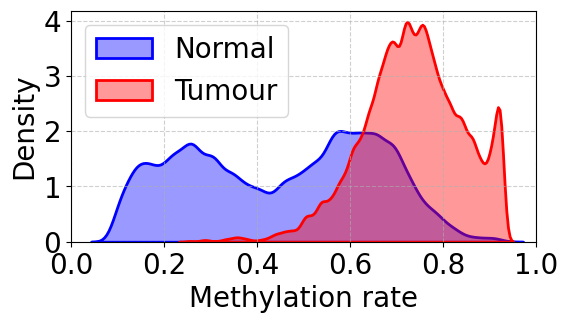

In [24]:
plot_filled_kde(data_chunked_agg["predictions_averaged"], data_chunked_agg["label"],name=name, figsize=(6,3))

In [26]:
roc_score = round(roc_auc_score(predictions_whole["label"],predictions_whole["prediction"])*100,1)
mcc = matthews_corrcoef(predictions_whole["label"],predictions_whole["prediction"]>0.5)
name = f"DNABERT-2E || ROC-AUC: {roc_score}% || MCC: {mcc:.1%}"

DNABERT-2E || ROC-AUC: 88.3% || MCC: 58.3% Cohen's d: 1.81, Means Difference: 0.424, 
 Pooled StDev: 0.234)


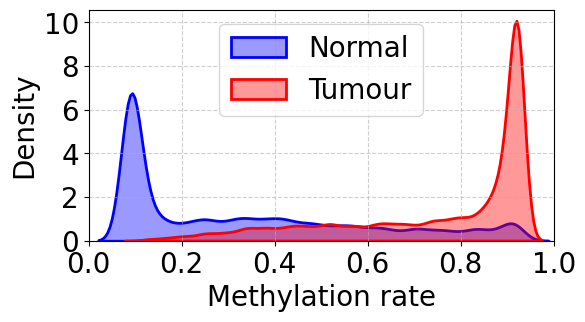

In [27]:
plot_filled_kde(predictions_whole["prediction"], predictions_whole["label"], name=name,figsize=(6,3))

In [28]:
roc_score = round(roc_auc_score(combined["label"],combined["combined_prediction"])*100,1)
mcc = matthews_corrcoef(combined["label"],combined["combined_prediction"]>0.5)
name = f"DNABERT-2E || ROC-AUC: {roc_score}% || MCC: {mcc:.1%}"

DNABERT-2E || ROC-AUC: 89.6% || MCC: 60.4% Cohen's d: 1.95, Means Difference: 0.352, 
 Pooled StDev: 0.181)


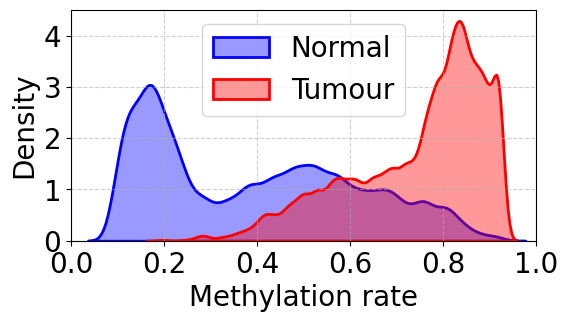

In [29]:
plot_filled_kde(combined["combined_prediction"], combined["label"], name=name,figsize=(6,3))

DNABERT-2E || ROC-AUC: 89.6% || Cohen's d: 0.22, Means Difference: 0.044, 
 Pooled StDev: 0.204)


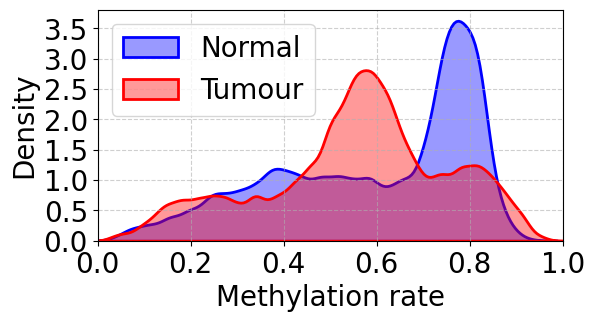

In [136]:
plot_filled_kde(test_data["methylation_rate"], test_data["label"], name=name,figsize=(6,3))

In [37]:
predictions_from_trimed_reads.label_ids

array([0, 0, 0, ..., 1, 1, 1])

In [38]:
roc_score = round(roc_auc_score(predictions_from_trimed_reads.label_ids,predictions_from_trimed_reads.predictions)*100,1)
mcc = matthews_corrcoef(predictions_from_trimed_reads.label_ids,predictions_from_trimed_reads.predictions>0.5)
name = f"DNABERT-2E || ROC-AUC: {roc_score}% || MCC: {mcc:.1%}"

DNABERT-2E || ROC-AUC: 83.1% || MCC: 49.1% Cohen's d: 1.42, Means Difference: 0.338, 
 Pooled StDev: 0.237)


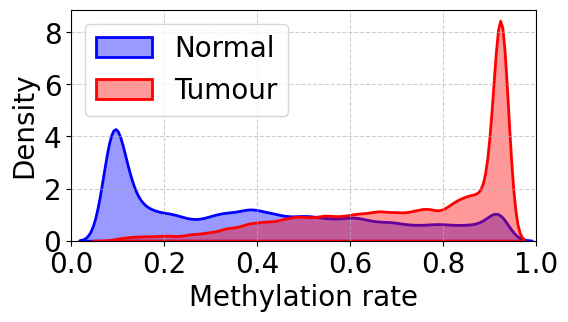

In [40]:
plot_filled_kde(predictions_from_trimed_reads.predictions, predictions_from_trimed_reads.label_ids, name=name,figsize=(6,3))